# Conjuntos

**Módulo:** 01 – Conjuntos e Funções

**Pré-requisitos:** conteúdo de [00_fundamentos_e_python/](../00_fundamentos_e_python/) (Python básico: `set`, laços `for`) e de [`0101a_nocoes_de_logica.ipynb`](0101a_nocoes_de_logica.ipynb) (quantificadores ∀/∃, negação, De Morgan em lógica)

**Objetivos de aprendizagem:**
- Reconhecer e descrever conjuntos de diferentes formas (extensão, compreensão, diagrama de Venn).
- Identificar relações entre conjuntos (igualdade, subconjunto) e realizar as operações básicas (união, interseção, diferença, complementar).
- Resolver problemas de contagem envolvendo união de conjuntos.
- Relacionar as Leis de De Morgan com operações lógicas em Python.

**Tempo estimado:** 60 a 75 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/01_conjuntos_e_funcoes/0102a_conjuntos.ipynb)

## Uma pesquisa que não fecha a conta

Uma pesquisa foi feita com **30 estudantes** de uma turma, perguntando sobre dois jogos:

- **18** disseram gostar de *Free Fire*.
- **15** disseram gostar de *Minecraft*.
- **7** disseram gostar dos **dois** jogos.

Se você somar 18 + 15, chega a 33 — só que a turma inteira tem 30 estudantes! Ninguém foi contado duas vezes na pesquisa, então onde está o erro?

A resposta tem a ver com **como contar coisas que se sobrepõem**, e é exatamente disso que trata a teoria de conjuntos: uma linguagem precisa para falar de coleções de objetos e das operações que fazemos com elas (juntar, sobrepor, comparar, excluir).

*Guarde essa conta que não fecha — vamos resolvê-la matematicamente lá na seção sobre contagem.*

## Conjunto, elemento e pertinência

- Um **conjunto** é uma coleção bem definida de objetos, chamados de **elementos**. "Bem definida" quer dizer que, dado qualquer objeto, sempre é possível decidir se ele pertence ou não ao conjunto — sem ambiguidade.
- Notação: se um elemento `x` pertence a um conjunto `A`, escrevemos **x ∈ A**. Se não pertence, **x ∉ A**.

📌 **Definição formal:**
- Wikipédia (PT): ["Conjunto (matemática)"](https://pt.wikipedia.org/wiki/Conjunto_(matem%C3%A1tica))

**Perguntas de checagem:**
1. 3 ∈ {1, 2, 3}? E 5 ∈ {1, 2, 3}?
2. "cachorro" ∈ {conjunto das frutas}? Por quê?

In [26]:
frutas = {"maçã", "banana", "uva"}

print("'maçã' in frutas:    ", "maçã" in frutas)
print("'cachorro' in frutas:", "cachorro" in frutas)

'maçã' in frutas:     True
'cachorro' in frutas: False


**Três formas de ver o mesmo conjunto:**

- **Algébrica:** {maçã, banana, uva}
- **Numérica/Python:** `frutas = {"maçã", "banana", "uva"}`, testado com o operador `in`
- **Gráfica:** um círculo representando o conjunto, com o elemento marcado dentro ou fora dele

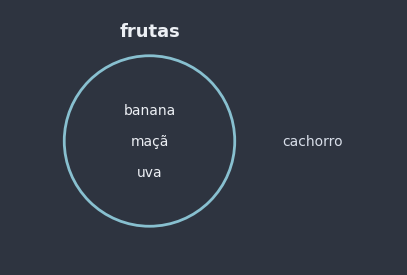

In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Paleta Nord usada em todos os diagramas deste notebook
NORD_FUNDO = "#2E3440"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_A = "#88C0D0"
COR_B = "#81A1C1"
COR_DESTAQUE = "#A3BE8C"

fig, ax = plt.subplots(figsize=(5, 3.4))
fig.patch.set_facecolor(NORD_FUNDO)
ax.set_facecolor(NORD_FUNDO)

ax.add_patch(Circle((0, 0), 1.1, facecolor="none", edgecolor=COR_A, linewidth=2))
ax.text(0, 1.35, "frutas", color=NORD_TEXTO, fontsize=13, ha="center", fontweight="bold")
frutas_ordenadas = sorted(frutas)
for i, fruta in enumerate(frutas_ordenadas):
    y = (len(frutas_ordenadas) - 1) / 2 * 0.4 - i * 0.4
    ax.text(0, y, fruta, color=NORD_TEXTO, fontsize=10, ha="center", va="center")
ax.text(2.1, 0, "cachorro", color=NORD_TEXTO_SEC, fontsize=10, ha="center", va="center")

ax.set_xlim(-1.8, 3.2)
ax.set_ylim(-1.6, 1.7)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

## Descrição de um conjunto: por extensão e por compreensão

- **Por extensão:** listamos os elementos um a um, entre chaves. Ex.: {2, 4, 6, 8}.
- **Por compreensão:** descrevemos uma **propriedade** que os elementos devem satisfazer, sem listá-los. Ex.: {x | x é par e 0 < x < 10}.

⚠️ **Erro comum:** escrever uma "compreensão" sem deixar claro o **quantificador** e o **domínio** de x — por exemplo, "conjunto dos x legais" não é uma descrição válida, porque não há como decidir com precisão quem pertence.

**Pergunta de checagem:**
1. Descreva por compreensão o conjunto {1, 4, 9, 16, 25}.

In [28]:
pares_extensao = {2, 4, 6, 8}
pares_compreensao = {x for x in range(1, 10) if x % 2 == 0}

print("Por extensão:   ", pares_extensao)
print("Por compreensão:", pares_compreensao)
print("São o mesmo conjunto?", pares_extensao == pares_compreensao)

Por extensão:    {8, 2, 4, 6}
Por compreensão: {8, 2, 4, 6}
São o mesmo conjunto? True


## Conjunto unitário e conjunto vazio

- **Conjunto unitário:** tem exatamente **um** elemento. Ex.: {7}.
- **Conjunto vazio:** não tem nenhum elemento. Notação: **∅** ou **{}**.

⚠️ **Erro comum:** confundir **{∅}** (um conjunto unitário, cujo único elemento é o conjunto vazio) com o próprio **∅** (que não tem elemento nenhum). {∅} tem 1 elemento; ∅ tem 0.

**Pergunta de checagem:**
1. {0} é um conjunto vazio?

In [29]:
vazio = set()
unitario = {0}

print("len(vazio):   ", len(vazio))
print("len(unitario):", len(unitario))
print("vazio == unitario?", vazio == unitario)

len(vazio):    0
len(unitario): 1
vazio == unitario? False


## Conjunto universo

- O **conjunto universo** (U) é o conjunto de referência que contém **todos** os elementos possíveis dentro de um contexto. Ele muda de acordo com o problema.
- Nas próximas seções vamos usar como universo de exemplo os alunos de uma turma fictícia — assim dá para brincar com os widgets escolhendo quem entra em cada conjunto.

📌 **Definição formal:**
- Wikipédia (PT): ["Conjunto universo"](https://pt.wikipedia.org/wiki/Conjunto_universo)

**Pergunta de checagem:**
1. Se o universo é "todos os números inteiros", o conjunto dos números pares é subconjunto de U? E o conjunto das frutas do início do notebook?

In [30]:
universo_turma = {"Ana", "Bruno", "Caio", "Duda", "Elis", "Fábio", "Gustavo", "Helena"}

print("Universo da turma:", universo_turma)
print("Quantidade de alunos:", len(universo_turma))

Universo da turma: {'Elis', 'Ana', 'Fábio', 'Bruno', 'Duda', 'Gustavo', 'Helena', 'Caio'}
Quantidade de alunos: 8


## Conjuntos iguais

Dois conjuntos são **iguais** quando têm exatamente os mesmos elementos. **Ordem e repetição não importam.**

⚠️ **Erro comum:** achar que {1, 2, 3} ≠ {3, 2, 1}, ou que escrever um elemento duas vezes cria um conjunto "maior" — {1, 1, 2} é exatamente o mesmo conjunto que {1, 2}.

**Pergunta de checagem:**
1. {2, 4, 6} e {6, 4, 2, 4} são iguais?

In [31]:
conjunto_x = {1, 2, 3}
conjunto_y = {3, 3, 2, 1}

print("conjunto_x:", conjunto_x)
print("conjunto_y:", conjunto_y)
print("São iguais?", conjunto_x == conjunto_y)

conjunto_x: {1, 2, 3}
conjunto_y: {1, 2, 3}
São iguais? True


## Subconjuntos

- Dizemos que **A é subconjunto de B** (A ⊆ B) quando **todo elemento de A também é elemento de B**.
- Se além disso existir algum elemento de B que não está em A, dizemos que A é subconjunto **próprio** (A ⊂ B).

📌 **Definição formal:**
- Wikipédia (PT): ["Subconjunto"](https://pt.wikipedia.org/wiki/Subconjunto)

**Perguntas de checagem:**
1. Todo conjunto é subconjunto de si mesmo?
2. Todo conjunto é subconjunto do conjunto universo?

In [32]:
aprovados = {"Ana", "Bruno", "Duda"}

print("aprovados ⊆ universo_turma?", aprovados.issubset(universo_turma))
print("aprovados ⊆ aprovados?     ", aprovados.issubset(aprovados))

aprovados ⊆ universo_turma? True
aprovados ⊆ aprovados?      True


Agora vamos visualizar isso com um **diagrama de Venn interativo**: você escolhe quem está em A e o diagrama, junto com o teste A ⊆ B, se atualiza na hora.

💡 **Dica:** o componente de diagrama definido abaixo (`diagrama_venn`) vai reaparecer, sem mudanças, em várias seções seguintes — só o que é destacado muda.

In [33]:
import ipywidgets as widgets

CENTRO_A = (-0.6, 0.0)
CENTRO_B = (0.6, 0.0)
RAIO = 1.2


def _distribuir_pontos(quantidade: int, centro: tuple[float, float]) -> list[tuple[float, float]]:
    '''Empilha `quantidade` pontos verticalmente ao redor de `centro`.

    Empilhar em uma única coluna (em vez de um grid) evita que nomes longos
    (como "Gustavo" ou "Helena") se encostem uns nos outros ou invadam a
    região vizinha do diagrama — o problema apareceria na direção horizontal
    se usássemos mais de uma coluna.
    '''
    if quantidade == 0:
        return []
    altura_maxima = 1.8
    passo_y = min(0.34, altura_maxima / (quantidade - 1)) if quantidade > 1 else 0.0
    return [
        (centro[0], centro[1] + ((quantidade - 1) / 2 - i) * passo_y)
        for i in range(quantidade)
    ]


def diagrama_venn(
    conjunto_a: set,
    conjunto_b: set,
    destaque: str = "nenhuma",
    titulo: str = "",
    nome_a: str = "A",
    nome_b: str = "B",
    mostrar_contagem: bool = False,
    ax=None,
) -> None:
    '''Desenha um diagrama de Venn de dois conjuntos, destacando uma região.

    Args:
        conjunto_a: elementos do conjunto A.
        conjunto_b: elementos do conjunto B.
        destaque: "nenhuma", "a", "b", "uniao", "intersecao", "diferenca_ab"
            (A − B) ou "diferenca_ba" (B − A).
        titulo: título exibido acima do diagrama.
        nome_a: rótulo exibido para o círculo A.
        nome_b: rótulo exibido para o círculo B.
        mostrar_contagem: se True, mostra a quantidade de elementos de cada
            região em vez de listar os elementos (útil para contagens grandes).
        ax: eixo do matplotlib onde desenhar; se None, cria uma figura nova.
    '''
    criou_figura = ax is None
    if criou_figura:
        fig, ax = plt.subplots(figsize=(6.5, 5))
        fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)

    if destaque == "a":
        ax.add_patch(Circle(CENTRO_A, RAIO, facecolor=COR_DESTAQUE, alpha=0.6, edgecolor="none"))
    elif destaque == "b":
        ax.add_patch(Circle(CENTRO_B, RAIO, facecolor=COR_DESTAQUE, alpha=0.6, edgecolor="none"))
    elif destaque == "uniao":
        ax.add_patch(Circle(CENTRO_A, RAIO, facecolor=COR_DESTAQUE, alpha=0.55, edgecolor="none"))
        ax.add_patch(Circle(CENTRO_B, RAIO, facecolor=COR_DESTAQUE, alpha=0.55, edgecolor="none"))
    elif destaque == "intersecao":
        recorte = Circle(CENTRO_A, RAIO, facecolor=COR_DESTAQUE, alpha=0.8, edgecolor="none")
        recorte.set_clip_path(Circle(CENTRO_B, RAIO, transform=ax.transData))
        ax.add_patch(recorte)
    elif destaque == "diferenca_ab":
        ax.add_patch(Circle(CENTRO_A, RAIO, facecolor=COR_DESTAQUE, alpha=0.6, edgecolor="none"))
        furo = Circle(CENTRO_B, RAIO, facecolor=NORD_FUNDO, edgecolor="none")
        furo.set_clip_path(Circle(CENTRO_A, RAIO, transform=ax.transData))
        ax.add_patch(furo)
    elif destaque == "diferenca_ba":
        ax.add_patch(Circle(CENTRO_B, RAIO, facecolor=COR_DESTAQUE, alpha=0.6, edgecolor="none"))
        furo = Circle(CENTRO_A, RAIO, facecolor=NORD_FUNDO, edgecolor="none")
        furo.set_clip_path(Circle(CENTRO_B, RAIO, transform=ax.transData))
        ax.add_patch(furo)

    ax.add_patch(Circle(CENTRO_A, RAIO, facecolor="none", edgecolor=COR_A, linewidth=2))
    ax.add_patch(Circle(CENTRO_B, RAIO, facecolor="none", edgecolor=COR_B, linewidth=2))

    so_a = sorted(conjunto_a - conjunto_b, key=str)
    so_b = sorted(conjunto_b - conjunto_a, key=str)
    inter = sorted(conjunto_a & conjunto_b, key=str)

    ancora_a = (CENTRO_A[0] - 0.4, 0.0)
    ancora_b = (CENTRO_B[0] + 0.4, 0.0)
    ancora_i = (0.0, 0.0)

    if mostrar_contagem:
        ax.text(*ancora_a, str(len(so_a)), color=NORD_TEXTO, fontsize=14, ha="center", va="center")
        ax.text(*ancora_b, str(len(so_b)), color=NORD_TEXTO, fontsize=14, ha="center", va="center")
        ax.text(*ancora_i, str(len(inter)), color=NORD_TEXTO, fontsize=14, ha="center", va="center")
    else:
        for elemento, (x, y) in zip(so_a, _distribuir_pontos(len(so_a), ancora_a)):
            ax.text(x, y, str(elemento), color=NORD_TEXTO, fontsize=9.5, ha="center", va="center")
        for elemento, (x, y) in zip(so_b, _distribuir_pontos(len(so_b), ancora_b)):
            ax.text(x, y, str(elemento), color=NORD_TEXTO, fontsize=9.5, ha="center", va="center")
        for elemento, (x, y) in zip(inter, _distribuir_pontos(len(inter), ancora_i)):
            ax.text(x, y, str(elemento), color=NORD_TEXTO, fontsize=9.5, ha="center", va="center")

    ax.text(CENTRO_A[0], RAIO + 0.15, nome_a, color=NORD_TEXTO, fontsize=13, ha="center", fontweight="bold")
    ax.text(CENTRO_B[0], RAIO + 0.15, nome_b, color=NORD_TEXTO, fontsize=13, ha="center", fontweight="bold")

    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-1.8, 1.8)
    ax.set_aspect("equal")
    ax.axis("off")
    if titulo:
        ax.set_title(titulo, color=NORD_TEXTO, pad=14)

    if criou_figura:
        plt.show()

In [ ]:
conjunto_b_fixo = {"Ana", "Bruno", "Duda", "Elis"}


def explorar_subconjunto(elementos_a):
    conjunto_a = set(elementos_a)
    diagrama_venn(conjunto_a, conjunto_b_fixo, destaque="a", titulo="A ⊆ B?")
    print("A ⊆ B?", conjunto_a.issubset(conjunto_b_fixo))


select_a = widgets.SelectMultiple(
    options=sorted(universo_turma), value=("Ana", "Bruno"), description="A:"
)
widgets.interact(explorar_subconjunto, elementos_a=select_a)

interactive(children=(SelectMultiple(description='A:', index=(0, 1), options=('Ana', 'Bruno', 'Caio', 'Duda', …

<function __main__.explorar_subconjunto(elementos_a)>

## Conjunto das partes P(A)

- O **conjunto das partes** de A, escrito P(A), é o conjunto de **todos os subconjuntos** de A — incluindo o próprio ∅ e o próprio A.
- Se A tem **n** elementos, então P(A) tem **2ⁿ** elementos (cada elemento pode estar "dentro" ou "fora" de um subconjunto, de forma independente).

📌 **Definição formal:** |P(A)| = 2ⁿ

🕵️ **Curiosidade histórica:** foi estudando o conjunto das partes que Georg Cantor mostrou que existem **infinitos de tamanhos diferentes** — o conjunto das partes de um conjunto infinito é sempre "maior" que o conjunto original. Essa ideia (bem informalmente, aqui) volta com tudo lá no módulo de Análise Combinatória.
- Wikipédia (PT): ["Conjunto potência"](https://pt.wikipedia.org/wiki/Conjunto_pot%C3%AAncia)

📎 **Conexão:** essa fórmula (2ⁿ) será usada de novo em Análise Combinatória (módulo 08), para contar o número de subconjuntos possíveis de um grupo.

**Pergunta de checagem:**
1. Quantos subconjuntos tem um conjunto com 4 elementos?

In [35]:
import itertools


def conjunto_das_partes(conjunto: set) -> list[set]:
    '''Gera o conjunto das partes (todos os subconjuntos) de um conjunto.

    Args:
        conjunto: conjunto original.

    Returns:
        Lista com todos os subconjuntos de `conjunto`, incluindo ∅ e ele mesmo.
    '''
    elementos = list(conjunto)
    partes = []
    for tamanho in range(len(elementos) + 1):
        for combinacao in itertools.combinations(elementos, tamanho):
            partes.append(set(combinacao))
    return partes


conjunto_pequeno = {"x", "y", "z"}
partes = conjunto_das_partes(conjunto_pequeno)

for p in partes:
    print(p if p else "∅")

print()
print(f"|P(A)| calculado: {len(partes)}   |   2^n previsto: {2 ** len(conjunto_pequeno)}")

∅
{'x'}
{'y'}
{'z'}
{'x', 'y'}
{'x', 'z'}
{'y', 'z'}
{'x', 'y', 'z'}

|P(A)| calculado: 8   |   2^n previsto: 8


In [36]:
import pandas as pd

tabela_partes = pd.DataFrame({
    "subconjunto": [str(p) if p else "∅" for p in partes],
    "tamanho": [len(p) for p in partes],
})
tabela_partes

,subconjunto,tamanho
0,∅,0
1,{'x'},1
2,{'y'},1
3,{'z'},1
4,"{'x', 'y'}",2
5,"{'x', 'z'}",2
6,"{'y', 'z'}",2
7,"{'x', 'y', 'z'}",3


## União de conjuntos

- A **união** de A e B (A ∪ B) é o conjunto formado por todos os elementos que estão em **A, em B, ou em ambos**.

📌 **Definição formal:** A ∪ B = {x | x ∈ A ou x ∈ B}

In [37]:
clube_xadrez = {"Ana", "Bruno", "Caio"}
clube_robotica = {"Bruno", "Caio", "Duda"}

print("Clube de xadrez ∪ Clube de robótica:", clube_xadrez | clube_robotica)
print("Usando .union():                   ", clube_xadrez.union(clube_robotica))

Clube de xadrez ∪ Clube de robótica: {'Duda', 'Ana', 'Caio', 'Bruno'}
Usando .union():                    {'Duda', 'Ana', 'Caio', 'Bruno'}


O widget abaixo é o **mesmo diagrama de Venn de antes**, agora com um seletor de operação — escolha os elementos de A e B e veja como cada operação recorta o diagrama.

**Pergunta de checagem:**
1. A ∪ ∅ é igual a quê?

In [38]:
OPERACOES = {
    "uniao": ("A ∪ B (união)", lambda a, b: a | b),
    "intersecao": ("A ∩ B (interseção)", lambda a, b: a & b),
    "diferenca_ab": ("A − B (diferença)", lambda a, b: a - b),
    "diferenca_ba": ("B − A (diferença)", lambda a, b: b - a),
}


def explorar_dois_conjuntos(operacao_inicial: str = "uniao") -> None:
    '''Widget reutilizável: escolha os elementos de A e B e a operação a aplicar.'''
    select_a = widgets.SelectMultiple(
        options=sorted(universo_turma), value=("Ana", "Bruno", "Caio"), description="A:"
    )
    select_b = widgets.SelectMultiple(
        options=sorted(universo_turma), value=("Bruno", "Caio", "Duda"), description="B:"
    )
    toggle_operacao = widgets.ToggleButtons(
        options=[(rotulo, chave) for chave, (rotulo, _) in OPERACOES.items()],
        value=operacao_inicial,
        description="Operação:",
    )

    def atualizar(elementos_a, elementos_b, operacao):
        conjunto_a, conjunto_b = set(elementos_a), set(elementos_b)
        rotulo, funcao = OPERACOES[operacao]
        resultado = funcao(conjunto_a, conjunto_b)
        diagrama_venn(conjunto_a, conjunto_b, destaque=operacao, titulo=rotulo)
        print(f"{rotulo} = {resultado or '∅'}   (tamanho: {len(resultado)})")

    widgets.interact(
        atualizar, elementos_a=select_a, elementos_b=select_b, operacao=toggle_operacao
    )


explorar_dois_conjuntos("uniao")

interactive(children=(SelectMultiple(description='A:', index=(0, 1, 2), options=('Ana', 'Bruno', 'Caio', 'Duda…

## Interseção de conjuntos

- A **interseção** de A e B (A ∩ B) é o conjunto formado pelos elementos que estão **simultaneamente em A e em B**.
- Quando A ∩ B = ∅, dizemos que A e B são **conjuntos disjuntos**.

📌 **Definição formal:** A ∩ B = {x | x ∈ A e x ∈ B}

**Pergunta de checagem:**
1. Se A ∩ B = ∅, o que isso significa sobre A e B?

In [14]:
print("Clube de xadrez ∩ Clube de robótica:", clube_xadrez & clube_robotica)
print("Usando .intersection():             ", clube_xadrez.intersection(clube_robotica))
print("São disjuntos?", clube_xadrez.isdisjoint(clube_robotica))

Clube de xadrez ∩ Clube de robótica: {'Bruno', 'Caio'}
Usando .intersection():              {'Bruno', 'Caio'}
São disjuntos? False


Mesmo widget de antes, agora começando em "interseção" — mude os elementos de A e B e observe como a região destacada muda de tamanho.

In [15]:
explorar_dois_conjuntos("intersecao")

interactive(children=(SelectMultiple(description='A:', index=(0, 1, 2), options=('Ana', 'Bruno', 'Caio', 'Duda…

## Problemas de contagem com união

Quando A e B se sobrepõem, somar n(A) + n(B) **conta duas vezes** quem está na interseção. Para corrigir isso:

📌 **Definição formal:** n(A ∪ B) = n(A) + n(B) − n(A ∩ B)

Voltando ao enigma do início: **Free Fire** (18 alunos) e **Minecraft** (15 alunos), com **7** alunos gostando dos dois.

In [16]:
free_fire = set(range(1, 19))                       # 18 alunos (1 a 18)
minecraft = set(range(1, 8)) | set(range(19, 27))   # 15 alunos (1 a 7, e 19 a 26)

n_uniao_direto = len(free_fire | minecraft)
n_uniao_formula = len(free_fire) + len(minecraft) - len(free_fire & minecraft)

print("n(Free Fire):             ", len(free_fire))
print("n(Minecraft):             ", len(minecraft))
print("n(Free Fire ∩ Minecraft): ", len(free_fire & minecraft))
print("n(Free Fire ∪ Minecraft) direto:                  ", n_uniao_direto)
print("n(Free Fire) + n(Minecraft) - n(interseção):       ", n_uniao_formula)
print("Soma ingênua (18 + 15):                           ", 18 + 15, "-> superconta os 7 que gostam dos dois")

n(Free Fire):              18
n(Minecraft):              15
n(Free Fire ∩ Minecraft):  7
n(Free Fire ∪ Minecraft) direto:                   26
n(Free Fire) + n(Minecraft) - n(interseção):        26
Soma ingênua (18 + 15):                            33 -> superconta os 7 que gostam dos dois


📎 **Conexão:** essa mesma fórmula de contagem reaparece em Probabilidade (módulo 08), na regra da adição: P(A ∪ B) = P(A) + P(B) − P(A ∩ B).

Brinque com os sliders abaixo: eles controlam n(A), n(B) e n(A ∩ B) diretamente (não elementos individuais), e o diagrama mostra a **contagem** em cada região.

**Pergunta de checagem:**
1. O que acontece com n(A ∪ B) quando n(A ∩ B) = 0?

In [17]:
def explorar_contagem(n_a: int, n_b: int, n_inter: int) -> None:
    n_inter = min(n_inter, n_a, n_b)
    so_a = {f"a{i}" for i in range(n_a - n_inter)}
    so_b = {f"b{i}" for i in range(n_b - n_inter)}
    inter = {f"i{i}" for i in range(n_inter)}
    conjunto_a, conjunto_b = so_a | inter, so_b | inter

    diagrama_venn(
        conjunto_a, conjunto_b, destaque="uniao", titulo="n(A ∪ B)", mostrar_contagem=True
    )
    print(f"n(A) = {n_a}, n(B) = {n_b}, n(A ∩ B) = {n_inter}")
    print(f"n(A ∪ B) = n(A) + n(B) - n(A ∩ B) = {n_a} + {n_b} - {n_inter} = {n_a + n_b - n_inter}")


widgets.interact(
    explorar_contagem,
    n_a=widgets.IntSlider(value=18, min=0, max=30, description="n(A):"),
    n_b=widgets.IntSlider(value=15, min=0, max=30, description="n(B):"),
    n_inter=widgets.IntSlider(value=7, min=0, max=30, description="n(A∩B):"),
)

interactive(children=(IntSlider(value=18, description='n(A):', max=30), IntSlider(value=15, description='n(B):…

<function __main__.explorar_contagem(n_a: int, n_b: int, n_inter: int) -> None>

## Propriedades dos conjuntos

- 📌 **Comutativa:** A ∪ B = B ∪ A, e A ∩ B = B ∩ A — não importa a ordem.
    - Exemplo: {1, 2} ∪ {2, 3} = {1, 2, 3} = {2, 3} ∪ {1, 2}.
- 📌 **Associativa:** (A ∪ B) ∪ C = A ∪ (B ∪ C), e o mesmo vale para ∩ — não importa o agrupamento.
    - Exemplo: ({1} ∪ {2}) ∪ {3} = {1} ∪ ({2} ∪ {3}) = {1, 2, 3}.
- 📌 **Distributiva:** A ∩ (B ∪ C) = (A ∩ B) ∪ (A ∩ C), e A ∪ (B ∩ C) = (A ∪ B) ∩ (A ∪ C).
    - Exemplo: {1,2} ∩ ({2,3} ∪ {4}) = {1,2} ∩ {2,3,4} = {2}; e ({1,2}∩{2,3}) ∪ ({1,2}∩{4}) = {2} ∪ ∅ = {2}.

**Pergunta de checagem:**
1. Um colega afirma que A − (B − C) = (A − B) − C sempre. Ele está certo? Teste com um exemplo antes de responder.

In [18]:
A = {1, 2, 3}
B = {3, 4, 5}
C = {5, 6, 7}

print("Comutativa (união):      ", (A | B) == (B | A))
print("Comutativa (interseção): ", (A & B) == (B & A))
print("Associativa (união):     ", ((A | B) | C) == (A | (B | C)))
print("Associativa (interseção):", ((A & B) & C) == (A & (B & C)))
print("Distributiva (∩ sobre ∪):", (A & (B | C)) == ((A & B) | (A & C)))
print("Distributiva (∪ sobre ∩):", (A | (B & C)) == ((A | B) & (A | C)))

# contraexemplo: diferença NÃO é associativa como a subtração de números seria
A2, B2, C2 = {1, 2}, {2}, {1}
print()
print("A - (B - C):", A2 - (B2 - C2))
print("(A - B) - C:", (A2 - B2) - C2)
print("A - (B - C) == (A - B) - C ?", (A2 - (B2 - C2)) == ((A2 - B2) - C2))

Comutativa (união):       True
Comutativa (interseção):  True
Associativa (união):      True
Associativa (interseção): True
Distributiva (∩ sobre ∪): True
Distributiva (∪ sobre ∩): True

A - (B - C): {1}
(A - B) - C: set()
A - (B - C) == (A - B) - C ? False


## Leis de De Morgan

📌 **Definição formal:**
- ∁(A ∪ B) = ∁A ∩ ∁B
- ∁(A ∩ B) = ∁A ∪ ∁B

(onde ∁X é o complementar de X em relação a um universo U)

📎 **Conexão:** é exatamente a mesma ideia das Leis de De Morgan em lógica, vistas em [`0101a_nocoes_de_logica.ipynb`](0101a_nocoes_de_logica.ipynb) — só trocamos "e"/"ou" por "∩"/"∪".

**Pergunta de checagem:**
1. Se U = {1, ..., 10}, A = {1, 2, 3} e B = {3, 4}, quem é ∁(A ∪ B)? E ∁A ∩ ∁B? Devem coincidir.

In [19]:
universo_numeros = set(range(1, 11))
A = {1, 2, 3, 4, 5}
B = {4, 5, 6, 7}


def complementar(conjunto: set, universo: set) -> set:
    '''Complementar de `conjunto` em relação a `universo` (universo - conjunto).'''
    return universo - conjunto


lado_esquerdo_1 = complementar(A | B, universo_numeros)
lado_direito_1 = complementar(A, universo_numeros) & complementar(B, universo_numeros)

lado_esquerdo_2 = complementar(A & B, universo_numeros)
lado_direito_2 = complementar(A, universo_numeros) | complementar(B, universo_numeros)

print("∁(A ∪ B) == ∁A ∩ ∁B ?", lado_esquerdo_1 == lado_direito_1)
print("∁(A ∩ B) == ∁A ∪ ∁B ?", lado_esquerdo_2 == lado_direito_2)

# a mesma ideia em lógica, com booleanos:
a, b = True, False
print("not(a or b) == (not a) and (not b):", (not (a or b)) == ((not a) and (not b)))

∁(A ∪ B) == ∁A ∩ ∁B ? True
∁(A ∩ B) == ∁A ∪ ∁B ? True
not(a or b) == (not a) and (not b): True


## Diferença de conjuntos

- A **diferença** A − B é o conjunto dos elementos que estão em A **mas não** em B.

📌 **Definição formal:** A − B = {x | x ∈ A e x ∉ B}

⚠️ **Erro comum:** achar que a diferença de conjuntos é comutativa como a subtração seria "intuitivamente" — em geral, **A − B ≠ B − A**.

**Pergunta de checagem:**
1. Dê um exemplo em que A − B = B − A. Isso sempre acontece?

In [20]:
A_dif = {"Ana", "Bruno", "Caio"}
B_dif = {"Bruno", "Duda"}

print("A - B:", A_dif - B_dif)
print("B - A:", B_dif - A_dif)
print("A - B == B - A?", (A_dif - B_dif) == (B_dif - A_dif))

A - B: {'Caio', 'Ana'}
B - A: {'Duda'}
A - B == B - A? False


De novo o mesmo widget, agora começando em "diferença A − B" — use o botão de operação para alternar entre A − B e B − A e veja que as regiões destacadas são diferentes.

In [21]:
explorar_dois_conjuntos("diferenca_ab")

interactive(children=(SelectMultiple(description='A:', index=(0, 1, 2), options=('Ana', 'Bruno', 'Caio', 'Duda…

## Complementar de B em A

- Quando B ⊆ A, a diferença A − B é chamada de **complementar de B em relação a A**, escrito ∁A B.
- Caso particular importante: quando A = U (o universo todo), o complementar de B em relação a U costuma ser escrito simplesmente **B̄**.

📌 **Definição formal:** ∁A B = A − B, definido quando B ⊆ A

**Pergunta de checagem:**
1. Qual a diferença entre "A − B" (visto na seção anterior) e "o complementar de B em A"?

In [22]:
select_b_complementar = widgets.SelectMultiple(
    options=sorted(universo_turma), value=("Bruno", "Duda"), description="B:"
)


def explorar_complementar(elementos_b):
    conjunto_b = set(elementos_b)
    complemento = universo_turma - conjunto_b
    diagrama_venn(
        universo_turma, conjunto_b, destaque="diferenca_ab",
        titulo="Complementar de B em U", nome_a="U", nome_b="B",
    )
    print("Complementar de B em U:", complemento)


widgets.interact(explorar_complementar, elementos_b=select_b_complementar)

interactive(children=(SelectMultiple(description='B:', index=(1, 3), options=('Ana', 'Bruno', 'Caio', 'Duda', …

<function __main__.explorar_complementar(elementos_b)>

## Resumo

| Símbolo | Nome | Python |
|---|---|---|
| x ∈ A | pertence | `x in A` |
| x ∉ A | não pertence | `x not in A` |
| ∅ | conjunto vazio | `set()` |
| A ⊆ B | subconjunto | `A.issubset(B)` |
| P(A) | conjunto das partes | `2 ** len(A)` elementos |
| A ∪ B | união | `A \| B` ou `A.union(B)` |
| A ∩ B | interseção | `A & B` ou `A.intersection(B)` |
| A − B | diferença | `A - B` ou `A.difference(B)` |
| ∁A B (ou B̄) | complementar de B (em A, ou em U) | `A - B` |

- **Contagem:** n(A ∪ B) = n(A) + n(B) − n(A ∩ B)
- **Propriedades:** comutativa e associativa (∪ e ∩); distributiva (∩ sobre ∪ e ∪ sobre ∩)
- **De Morgan:** ∁(A ∪ B) = ∁A ∩ ∁B  |  ∁(A ∩ B) = ∁A ∪ ∁B

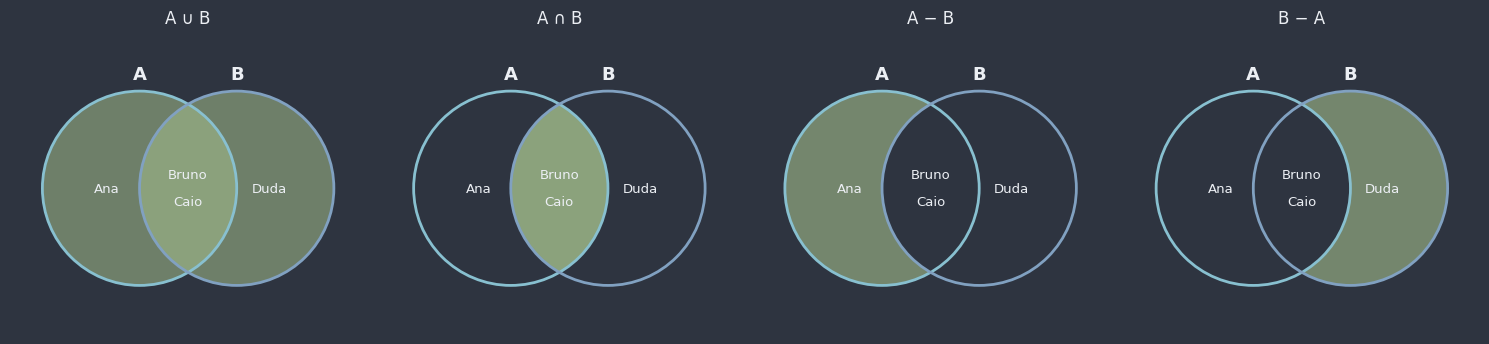

In [23]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4.2))
fig.patch.set_facecolor(NORD_FUNDO)

A_resumo = {"Ana", "Bruno", "Caio"}
B_resumo = {"Bruno", "Caio", "Duda"}

configuracoes = [
    ("uniao", "A ∪ B"),
    ("intersecao", "A ∩ B"),
    ("diferenca_ab", "A − B"),
    ("diferenca_ba", "B − A"),
]

for ax, (destaque, titulo) in zip(axs, configuracoes):
    diagrama_venn(A_resumo, B_resumo, destaque=destaque, titulo=titulo, ax=ax)

plt.tight_layout()
plt.show()

## Exercícios

**Básico**
1. Verificar pertinência de elementos em um conjunto.
2. Descrever por compreensão um conjunto dado por extensão.
3. Classificar conjuntos como vazio, unitário ou nenhum dos dois.

**Intermediário**
1. Determinar se um conjunto é subconjunto de outro.
2. Calcular |P(A)| para um conjunto de 4 elementos.
3. Combinar união, interseção, diferença e complementar num mesmo problema.
4. Aplicar as Leis de De Morgan em conjuntos.

**Desafio**
1. Problema de contagem com três conjuntos (A ∪ B ∪ C), adaptando a fórmula da seção de contagem.
2. Provar por casos que uma identidade envolvendo diferença e interseção sempre vale.

Resolva cada exercício substituindo as reticências `...` e rode a célula de verificação em seguida para conferir sua resposta.

O gabarito comentado de todos os exercícios está em [`0102b_conjuntos_gabarito.ipynb`](0102b_conjuntos_gabarito.ipynb) — só dê uma olhada depois de tentar por conta própria.

In [ ]:
# Exercício Básico 1: pertinência
numeros_primos_ate_20 = {2, 3, 5, 7, 11, 13, 17, 19}

pertence_7 = ...  # 7 pertence a numeros_primos_ate_20?
pertence_9 = ...  # 9 pertence a numeros_primos_ate_20?

print(pertence_7, pertence_9)

In [ ]:
# Verificação
assert pertence_7 is True, "Tente de novo, revise o passo 1: 7 é primo e está no conjunto."
assert pertence_9 is False, "Tente de novo, revise o passo 1: 9 = 3 x 3 não é primo."
print("Certo!")

In [ ]:
# Exercício Básico 2: descreva por compreensão o conjunto dado por extensão abaixo
multiplos_de_3 = {3, 6, 9, 12, 15, 18, 21, 24, 27, 30}

# Complete a compreensão abaixo para gerar o mesmo conjunto
multiplos_de_3_compreensao = {... for x in range(1, 11)}

print(multiplos_de_3_compreensao == multiplos_de_3)

In [ ]:
# Verificação
assert multiplos_de_3_compreensao == multiplos_de_3, (
    "Tente de novo, revise o passo 2: cada elemento é um múltiplo de 3, use x * 3."
)
print("Certo!")

In [ ]:
# Exercício Básico 3: classifique como "vazio", "unitario" ou "nenhum"
conjunto_a = {x for x in range(5, 10) if x > 100}  # nenhum numero nesse intervalo é > 100
conjunto_b = {x for x in range(1, 10) if x == 7}
conjunto_c = {1, 2, 3}

classe_a = ...
classe_b = ...
classe_c = ...

print(classe_a, classe_b, classe_c)

In [ ]:
# Verificação
assert classe_a == "vazio", "Tente de novo, revise o passo 3: nenhum x no intervalo satisfaz x > 100."
assert classe_b == "unitario", "Tente de novo, revise o passo 3: só x = 7 satisfaz a condição."
assert classe_c == "nenhum", "Tente de novo, revise o passo 3: {1, 2, 3} tem 3 elementos."
print("Certo!")

In [ ]:
# Exercício Intermediário 1: subconjuntos
turma_matematica = {"Ana", "Bruno", "Caio", "Duda", "Elis"}
clube_xadrez_int = {"Ana", "Duda"}
clube_robotica_int = {"Ana", "Fábio"}

clube_xadrez_subconjunto = ...    # clube_xadrez_int é subconjunto de turma_matematica?
clube_robotica_subconjunto = ...  # clube_robotica_int é subconjunto de turma_matematica?

print(clube_xadrez_subconjunto, clube_robotica_subconjunto)

In [ ]:
# Verificação
assert clube_xadrez_subconjunto is True, "Tente de novo, revise o passo 1: use .issubset()."
assert clube_robotica_subconjunto is False, (
    "Tente de novo, revise o passo 1: Fábio não está na turma_matematica."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 2: conjunto das partes
conjunto_desafio_2 = {"a", "b", "c", "d"}

partes_desafio_2 = conjunto_das_partes(...)  # complete a chamada da função
quantidade_partes = len(partes_desafio_2)

print(quantidade_partes)

In [ ]:
# Verificação
assert quantidade_partes == 16, (
    "Tente de novo, revise o passo 2: |P(A)| = 2^n, e o conjunto tem 4 elementos."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 3: combine união, interseção, diferença e complementar
universo_ex = set(range(1, 11))
A_ex = {1, 2, 3, 4, 5}
B_ex = {4, 5, 6, 7}

uniao_ex = ...          # A_ex ∪ B_ex
intersecao_ex = ...     # A_ex ∩ B_ex
diferenca_ex = ...      # A_ex - B_ex
complementar_a_ex = ... # complementar de A_ex em relação a universo_ex

print(uniao_ex, intersecao_ex, diferenca_ex, complementar_a_ex)

In [ ]:
# Verificação
assert uniao_ex == {1, 2, 3, 4, 5, 6, 7}, "Tente de novo, revise o passo 3: união junta todos os elementos."
assert intersecao_ex == {4, 5}, "Tente de novo, revise o passo 3: interseção é o que está nos dois."
assert diferenca_ex == {1, 2, 3}, "Tente de novo, revise o passo 3: A - B remove quem também está em B."
assert complementar_a_ex == {6, 7, 8, 9, 10}, (
    "Tente de novo, revise o passo 3: complementar de A em U é U - A."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: aplique De Morgan
universo_ex2 = set(range(1, 9))
P_ex = {1, 2, 3, 4}
Q_ex = {3, 4, 5, 6}

lado_esquerdo_ex = ...  # complementar de (P_ex ∪ Q_ex) em universo_ex2
lado_direito_ex = ...   # complementar de P_ex ∩ complementar de Q_ex, em universo_ex2

print(lado_esquerdo_ex == lado_direito_ex)

In [ ]:
# Verificação
assert lado_esquerdo_ex == (universo_ex2 - (P_ex | Q_ex)), (
    "Tente de novo, revise o passo 4: lado esquerdo é o complementar da união."
)
assert lado_direito_ex == ((universo_ex2 - P_ex) & (universo_ex2 - Q_ex)), (
    "Tente de novo, revise o passo 4: lado direito é a interseção dos complementares."
)
assert lado_esquerdo_ex == lado_direito_ex, "As duas leis de De Morgan devem coincidir."
print("Certo!")

In [ ]:
# Exercício Desafio 1: contagem com três conjuntos
# 40 pessoas pesquisadas sobre três apps: Instagram (I), TikTok (T) e WhatsApp (W)
n_I, n_T, n_W = 25, 20, 30
n_I_T, n_I_W, n_T_W = 12, 15, 10
n_I_T_W = 5

# Adapte a fórmula de inclusão-exclusão para três conjuntos:
# n(I ∪ T ∪ W) = n(I) + n(T) + n(W) - n(I∩T) - n(I∩W) - n(T∩W) + n(I∩T∩W)
n_uniao_tres = ...

print(n_uniao_tres)

In [ ]:
# Verificação
esperado = n_I + n_T + n_W - n_I_T - n_I_W - n_T_W + n_I_T_W
assert n_uniao_tres == esperado, (
    "Tente de novo, revise o passo: a fórmula de três conjuntos soma os três, "
    "subtrai as três interseções de pares, e soma de volta a interseção tripla."
)
print("Certo!")

In [ ]:
# Exercício Desafio 2: prove por casos que (A - B) ∪ (A ∩ B) == A sempre,
# testando TODOS os pares de subconjuntos de um universo pequeno.
universo_prova = {1, 2, 3}
subconjuntos_prova = conjunto_das_partes(universo_prova)

resultados = [
    ((A_teste - B_teste) | (A_teste & B_teste)) == A_teste
    for A_teste in subconjuntos_prova
    for B_teste in subconjuntos_prova
]

# A afirmação é sempre verdadeira nesse universo se TODOS os testes deram True
sempre_verdadeira = ...  # use all(...) sobre a lista resultados

print(sempre_verdadeira)

In [ ]:
# Verificação
assert sempre_verdadeira == all(resultados), (
    "Tente de novo, revise o passo: use all(resultados) para verificar todos os casos."
)
assert sempre_verdadeira is True, "A igualdade realmente vale sempre — revise a lista `resultados`."
print("Certo!")

## Conexões

**Isso depende de:** [00_fundamentos_e_python/](../00_fundamentos_e_python/) (sets em Python) e [`0101a_nocoes_de_logica.ipynb`](0101a_nocoes_de_logica.ipynb) (quantificadores ∀/∃, negação, De Morgan em lógica)

**Isso será usado em:**
- Próximo notebook do módulo, sobre funções — que usa diretamente subconjuntos e produto cartesiano
- Análise Combinatória — módulo 08 (conjunto das partes, contagem)
- Probabilidade — módulo 08 (contagem com união, De Morgan, complementar de eventos)